# 02 — Gráficos de línea y barra

Los dos tipos de gráfico más comunes en análisis de negocio. Líneas para tendencias en el tiempo, barras para comparar categorías.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from pathlib import Path

def find_project_root():
    for parent in [Path.cwd()] + list(Path.cwd().parents):
        if (parent / 'data').exists():
            return parent

ROOT  = find_project_root()
TRAIN = ROOT / 'data' / 'external' / 'train.csv'
AIR   = ROOT / 'data' / 'external' / 'Listings.csv'

df = pd.read_csv(TRAIN, low_memory=False)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['mes'] = df['Order Date'].dt.to_period('M').astype(str)
print(df.shape)


(9800, 19)


## Gráfico de línea — ventas mensuales

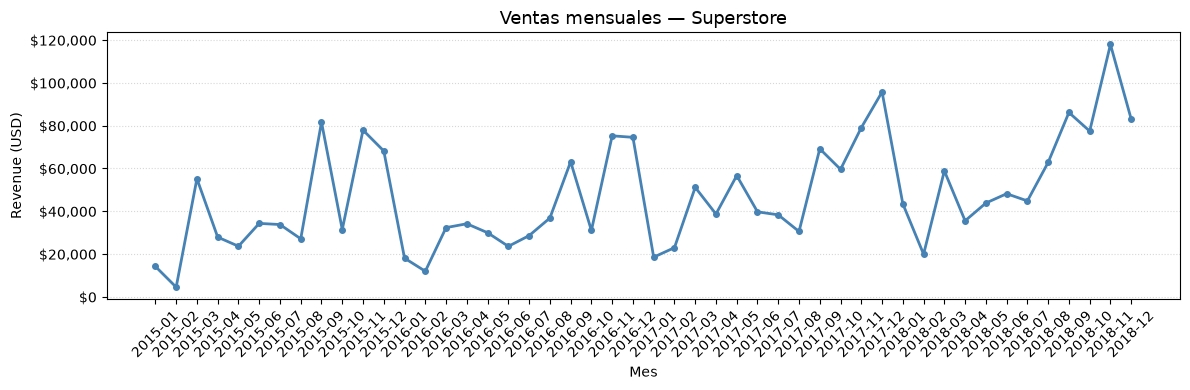

In [2]:
ventas_mes = (
    df.groupby('mes')['Sales']
    .sum()
    .reset_index()
    .rename(columns={'Sales': 'revenue'})
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    ventas_mes['mes'],
    ventas_mes['revenue'],
    color='steelblue',
    linewidth=2,
    marker='o',         # punto en cada dato
    markersize=4,
)

ax.set_title('Ventas mensuales — Superstore', fontsize=13)
ax.set_xlabel('Mes')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


## Líneas múltiples — ventas por categoría

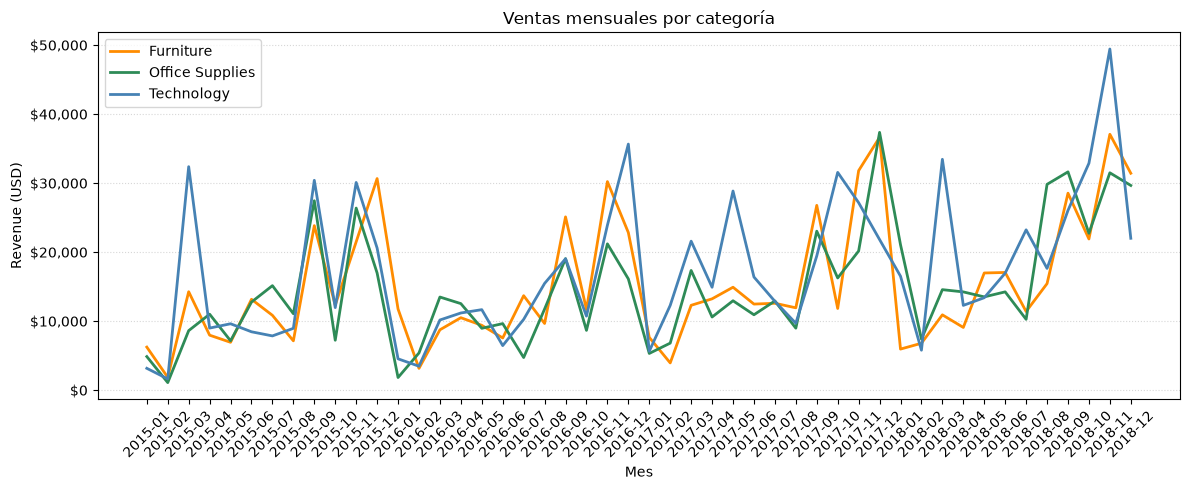

In [3]:
ventas_cat = (
    df.groupby(['mes', 'Category'])['Sales']
    .sum()
    .reset_index()
)

colores = {'Technology': 'steelblue', 'Furniture': 'darkorange', 'Office Supplies': 'seagreen'}

fig, ax = plt.subplots(figsize=(12, 5))

for categoria, grupo in ventas_cat.groupby('Category'):
    ax.plot(
        grupo['mes'],
        grupo['Sales'],
        label=categoria,
        color=colores[categoria],
        linewidth=2,
    )

ax.set_title('Ventas mensuales por categoría')
ax.set_xlabel('Mes')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


## Gráfico de barras vertical

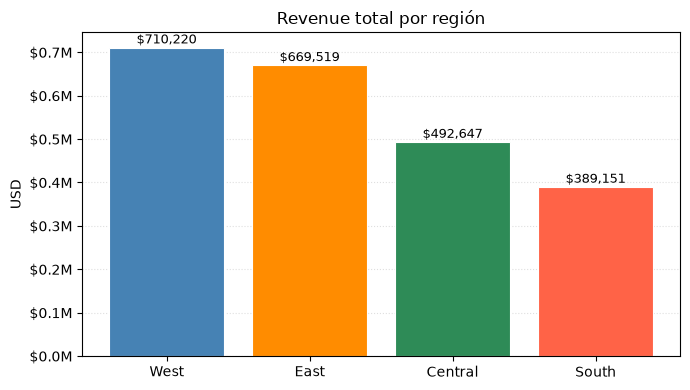

In [4]:
ventas_region = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))

barras = ax.bar(
    ventas_region['Region'],
    ventas_region['Sales'],
    color=['steelblue', 'darkorange', 'seagreen', 'tomato'],
    edgecolor='white',
    linewidth=0.8,
)

# Etiquetas encima de cada barra
for barra in barras:
    h = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        h + 3000,
        f'${h:,.0f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Revenue total por región')
ax.set_ylabel('USD')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_axisbelow(True)   # la grilla queda detrás de las barras

plt.tight_layout()
plt.show()


## Barras horizontales — mejor para etiquetas largas

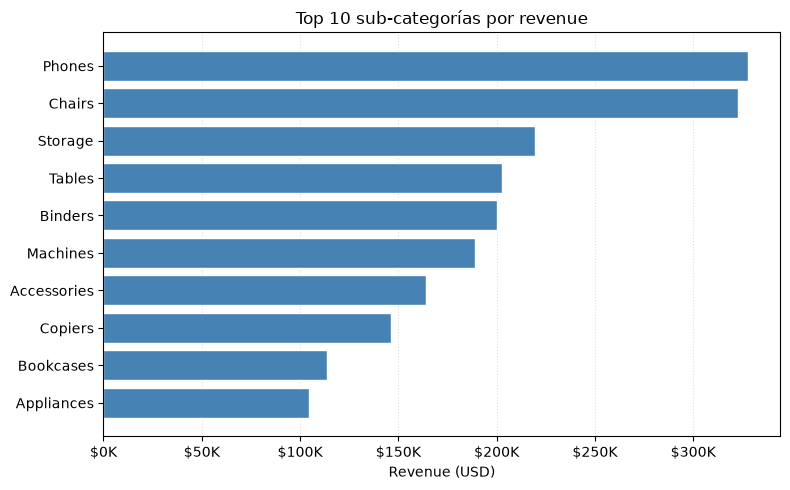

In [5]:
top_subcats = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values()
    .tail(10)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(top_subcats.index, top_subcats.values, color='steelblue', edgecolor='white')

ax.set_title('Top 10 sub-categorías por revenue')
ax.set_xlabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## Barras agrupadas — comparar categorías dentro de grupos

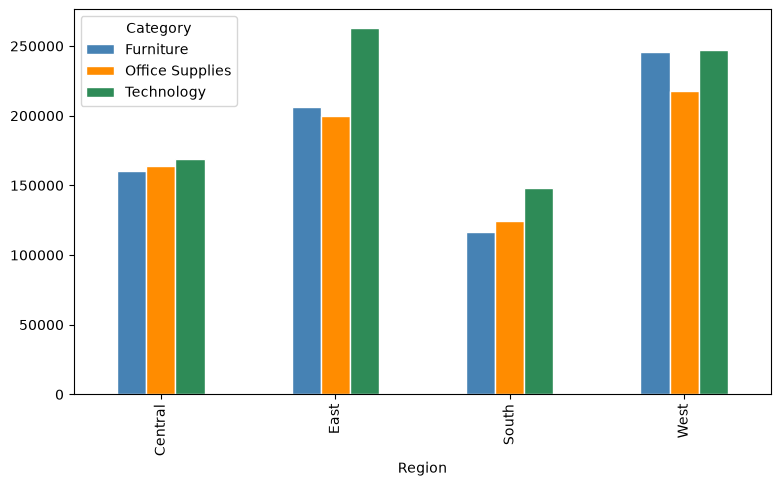

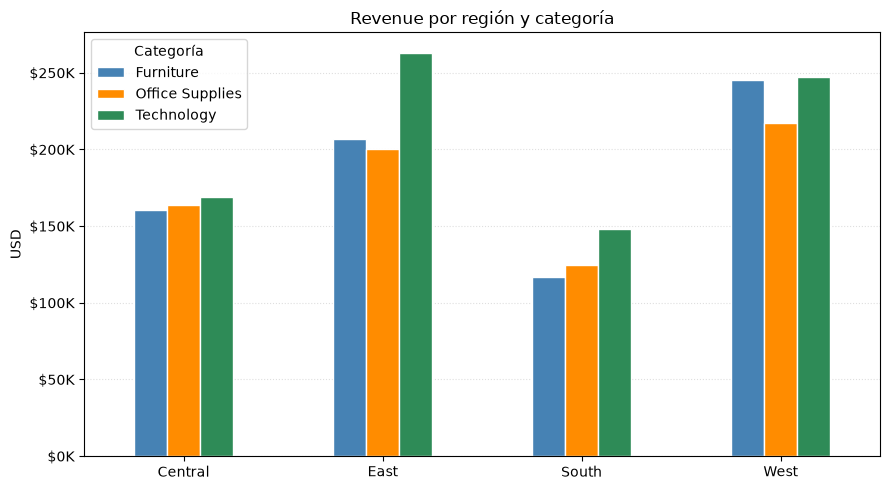

In [6]:
ventas_region_cat = (
    df.groupby(['Region', 'Category'])['Sales']
    .sum()
    .unstack('Category')
)

ventas_region_cat.plot(
    kind='bar',
    figsize=(9, 5),
    color=['steelblue', 'darkorange', 'seagreen'],
    edgecolor='white',
    ax=plt.subplots(figsize=(9, 5))[1],  # pasar el ax del subplots
)

# Forma más explícita:
fig, ax = plt.subplots(figsize=(9, 5))
ventas_region_cat.plot(kind='bar', ax=ax,
                       color=['steelblue', 'darkorange', 'seagreen'],
                       edgecolor='white')

ax.set_title('Revenue por región y categoría')
ax.set_xlabel('')
ax.set_ylabel('USD')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Categoría')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


---
## Resumen

| Tipo | Función | Cuándo usarlo |
|------|---------|---------------|
| Línea | `ax.plot()` | Tendencias en el tiempo |
| Barra vertical | `ax.bar()` | Comparar N categorías (≤8) |
| Barra horizontal | `ax.barh()` | Etiquetas largas, rankings |
| Barras agrupadas | `df.plot(kind='bar', ax=ax)` | Comparar sub-grupos dentro de categorías |
